In [1]:
!pip install -q bertopic shap wordcloud matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.7 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import seaborn as sns
import spacy
from collections import Counter
from bertopic import BERTopic
from umap import UMAP
from transformers import pipeline
import torch

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [4]:
# Load Data
from google.colab import drive
drive.mount('/gdrive')
df = pd.read_csv("/gdrive/MyDrive/OrchidPharmed/hospital_with_neutral_labels_new.csv")
# Ensure data is clean
df['Feedback'] = df['Feedback'].astype(str)

Mounted at /gdrive


--- ANALYZING KEYWORDS ---


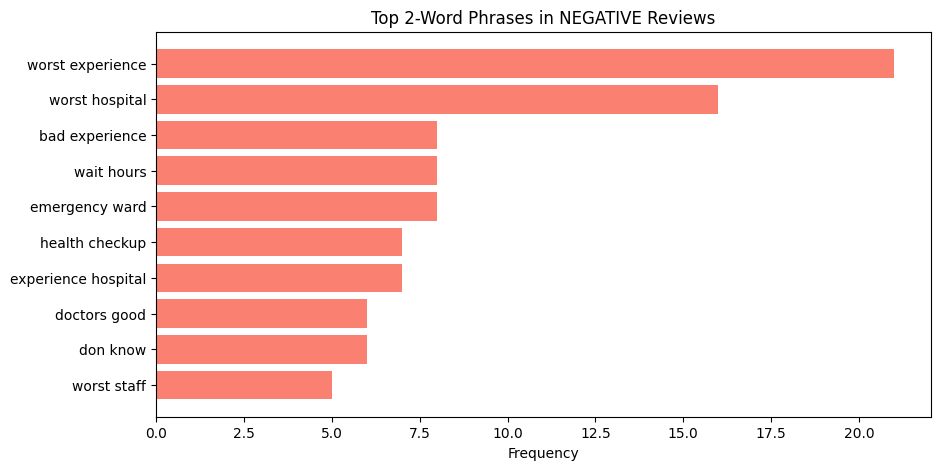

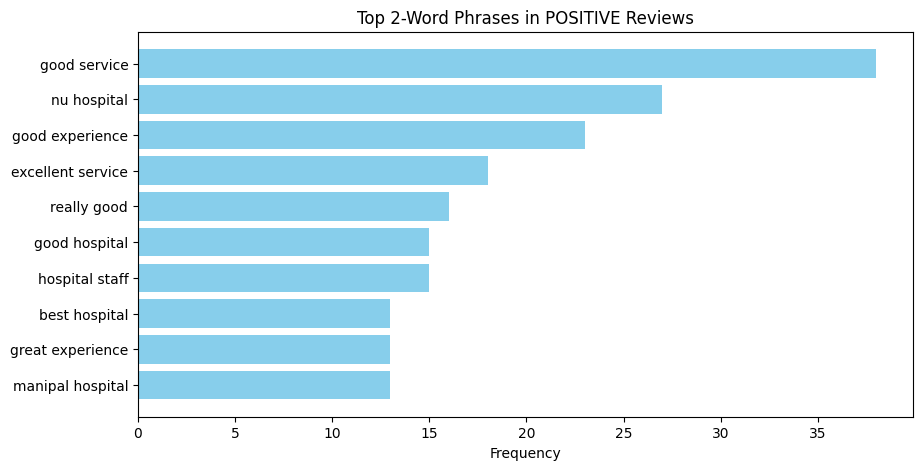

In [5]:
## PART A: Frequent Keywords (N-grams)
def get_top_ngrams(corpus, n=2, top_k=10):
    """
    Extracts the most frequent n-word phrases (bigrams/trigrams).
    """
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:top_k]

def plot_ngrams(data, title, color):
    words, counts = zip(*data)
    plt.figure(figsize=(10, 5))
    plt.barh(words, counts, color=color)
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.xlabel("Frequency")
    plt.show()

print("--- ANALYZING KEYWORDS ---")

# Analyze Negative Reviews (Label 0)
neg_reviews = df[df['sentiment_label_3class'] == 0]['Feedback']
if not neg_reviews.empty:
    top_neg = get_top_ngrams(neg_reviews, n=2, top_k=10)
    plot_ngrams(top_neg, "Top 2-Word Phrases in NEGATIVE Reviews", "salmon")

# Analyze Positive Reviews (Label 1)
pos_reviews = df[df['sentiment_label_3class'] == 1]['Feedback']
if not pos_reviews.empty:
    top_pos = get_top_ngrams(pos_reviews, n=2, top_k=10)
    plot_ngrams(top_pos, "Top 2-Word Phrases in POSITIVE Reviews", "skyblue")


In [6]:
 #PART B: High-Level Themes (Topic Modeling)
# Load Data
df = pd.read_csv("/gdrive/MyDrive/OrchidPharmed/hospital_with_neutral_labels_new.csv")
df['Feedback'] = df['Feedback'].astype(str)

# Define a function to avoid repeating code
def analyze_specific_class(dataframe, class_label, class_name):
    print(f"\n==================================================")
    print(f"   ANALYZING THEMES FOR CLASS {class_label} ({class_name})")
    print(f"==================================================")

    # Filter only the specific class
    subset = dataframe[dataframe['sentiment_label_3class'] == class_label]['Feedback'].tolist()

    if len(subset) < 10:
        print(f"Not enough data for Class {class_label} to model topics.")
        return

    # --- FIX RANDOMNESS HERE ---
    # We define UMAP explicitly with a random_state (seed)
    # n_components=5 is the default for BERTopic
    umap_model = UMAP(
        n_neighbors=15,
        n_components=5,
        min_dist=0.0,
        metric='cosine',
        random_state=42  # <--- This number ensures reproducibility
    )

    # Initialize BERTopic with the fixed UMAP model
    topic_model = BERTopic(
        umap_model=umap_model, # <--- Pass the fixed model here
        language="english",
        calculate_probabilities=False,
        verbose=True
    )

    # Fit the model
    topics, probs = topic_model.fit_transform(subset)

    # Display Info
    print(topic_model.get_topic_info().head(8))

    # Visualize
    fig = topic_model.visualize_barchart(
        top_n_topics=8,
        title=f"Dominant Themes in Class {class_label} ({class_name})"
    )
    fig.show()

#Run the Analysis

# Analyze Class 0 (Usually Negative)
analyze_specific_class(df, 0, "Negative/Class 0")

# Analyze Class 1 (Usually Positive)
analyze_specific_class(df, 1, "Positive/Class 1")

2026-01-06 11:35:22,484 - BERTopic - Embedding - Transforming documents to embeddings.



   ANALYZING THEMES FOR CLASS 0 (Negative/Class 0)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

2026-01-06 11:35:47,594 - BERTopic - Embedding - Transforming documents to embeddings.



   ANALYZING THEMES FOR CLASS 1 (Positive/Class 1)


Batches:   0%|          | 0/21 [00:00<?, ?it/s]

2026-01-06 11:35:50,258 - BERTopic - Embedding - Completed ✓
2026-01-06 11:35:50,261 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-01-06 11:35:56,086 - BERTopic - Dimensionality - Completed ✓
2026-01-06 11:35:56,089 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-06 11:35:56,174 - BERTopic - Cluster - Completed ✓
2026-01-06 11:35:56,191 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-06 11:35:56,257 - BERTopic - Representation - Completed ✓


   Topic  Count                  Name  \
0     -1      9  -1_dilip_kumar_by_in   
1      0    625   0_and_the_very_good   
2      1     12   1_fortis_the_and_is   

                                      Representation  \
0  [dilip, kumar, by, in, helping, service, us, g...   
1  [and, the, very, good, hospital, to, is, for, ...   
2  [fortis, the, and, is, experience, team, for, ...   

                                 Representative_Docs  
0  [Good service by dilip Kumar in helping us fin...  
1  [Had an emergency visit to the hospital with m...  
2  [My entire pregnancy experience at Fortis was ...  


Extracting Adjective-Noun pairs from Negative reviews...


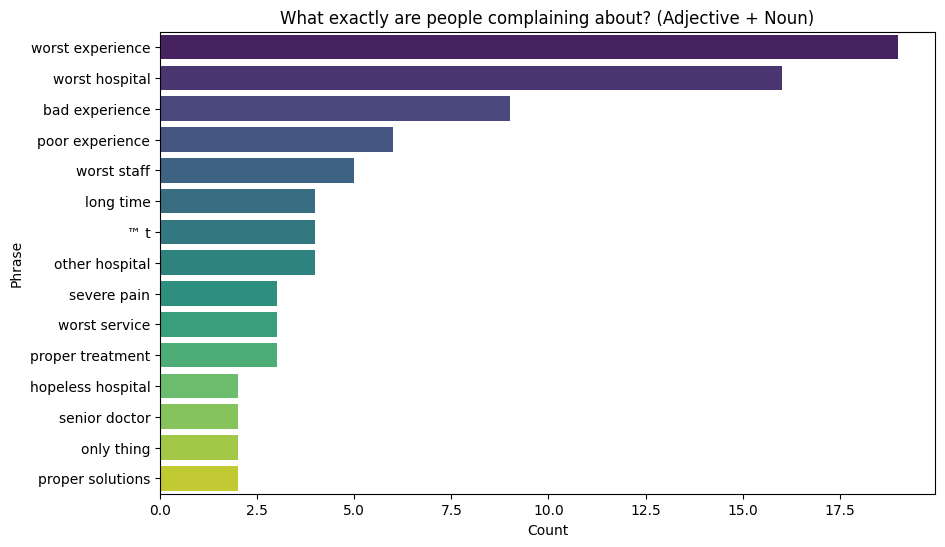

In [7]:
# For negative reviews
# Load spaCy
nlp = spacy.load("en_core_web_sm")

# Load your data
df = pd.read_csv("/gdrive/MyDrive/OrchidPharmed/hospital_with_neutral_labels_new.csv")
neg_reviews = df[df['sentiment_label_3class'] == 0]['Feedback'].astype(str).tolist()

def extract_adjective_noun_pairs(texts):
    pairs = []
    for doc in nlp.pipe(texts, disable=["ner"]):
        for token in doc:
            # Check if token is an adjective
            if token.pos_ == "ADJ":
                # Check children for nouns being modified
                # OR check head if the adjective is the child
                if token.head.pos_ == "NOUN":
                    pairs.append(f"{token.text.lower()} {token.head.text.lower()}")
    return pairs

# Run extraction on NEGATIVE reviews
print("Extracting Adjective-Noun pairs from Negative reviews...")
neg_pairs = extract_adjective_noun_pairs(neg_reviews)

# Count and Plot
pair_counts = Counter(neg_pairs).most_common(15)

# Convert to DataFrame for plotting
pdf = pd.DataFrame(pair_counts, columns=['Phrase', 'Count'])

plt.figure(figsize=(10, 6))
sns.barplot(data=pdf, y='Phrase', x='Count', palette='viridis')
plt.title("What exactly are people complaining about? (Adjective + Noun)")
plt.show()

Extracting Adjective-Noun pairs from Positive reviews...


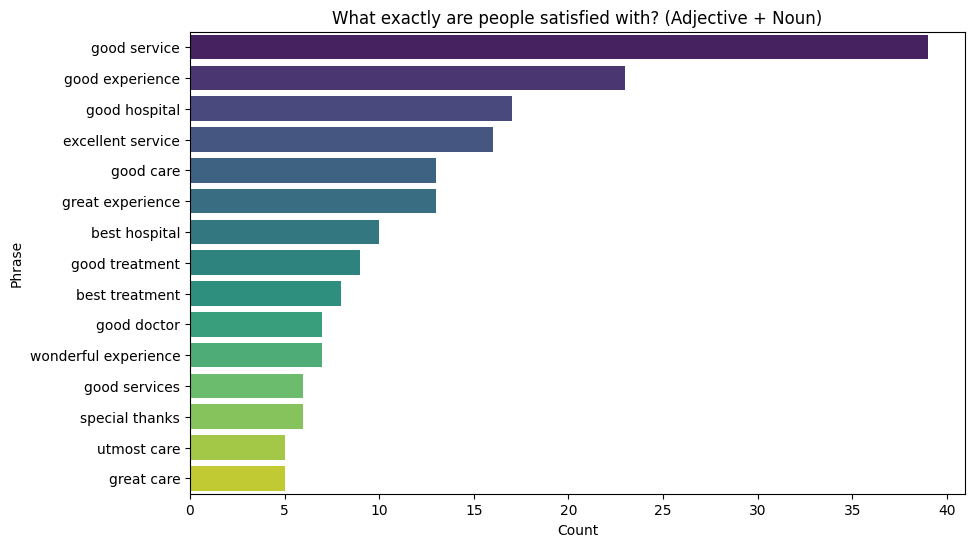

646
['Good and clean hospital. There is great team of doctors and good OT facility. The medical facilities are all great with good in-patient post operative care by doctors, nurses. The housekeeping staff is also good but they can respond to calls from the room a little faster. ', 'I have visited to take my second dose and Process was really smooth. Hospitality from all staffs are really appreciable. Shanti tooks good care and provide all details before vaccination. Thank you.', ' That person was slightly clueless and offered only one package. But once i got to the hospital, I found a better and more economical one and decided to go ahead', 'Good and clean hospital.  The medical facilities are all great with good in-patient post operative care by doctors, nurses. The housekeeping staff is also good but they can respond to calls from the room a little faster.', 'Over all experience was good, starting from reception,lab services and doctors interaction.Doctor with whom I have had consult

In [9]:
# for positive reviews
# Load spaCy
nlp = spacy.load("en_core_web_sm")

# Load your data
df = pd.read_csv("/gdrive/MyDrive/OrchidPharmed/hospital_with_neutral_labels_new.csv")
neg_reviews = df[df['sentiment_label_3class'] == 1]['Feedback'].astype(str).tolist()

def extract_adjective_noun_pairs(texts):
    pairs = []
    for doc in nlp.pipe(texts, disable=["ner"]):
        for token in doc:
            # Check if token is an adjective
            if token.pos_ == "ADJ":
                # Check children for nouns being modified
                # OR check head if the adjective is the child
                if token.head.pos_ == "NOUN":
                    pairs.append(f"{token.text.lower()} {token.head.text.lower()}")
    return pairs

# Run extraction on NEGATIVE reviews
print("Extracting Adjective-Noun pairs from Positive reviews...")
neg_pairs = extract_adjective_noun_pairs(neg_reviews)

# Count and Plot
pair_counts = Counter(neg_pairs).most_common(15)

# Convert to DataFrame for plotting
pdf = pd.DataFrame(pair_counts, columns=['Phrase', 'Count'])

plt.figure(figsize=(10, 6))
sns.barplot(data=pdf, y='Phrase', x='Count', palette='viridis')
plt.title("What exactly are people satisfied with? (Adjective + Noun)")
plt.show()

print(len(neg_reviews))
print(neg_reviews)

Total Positive Reviews: 646


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Classifying 646 reviews into categories...


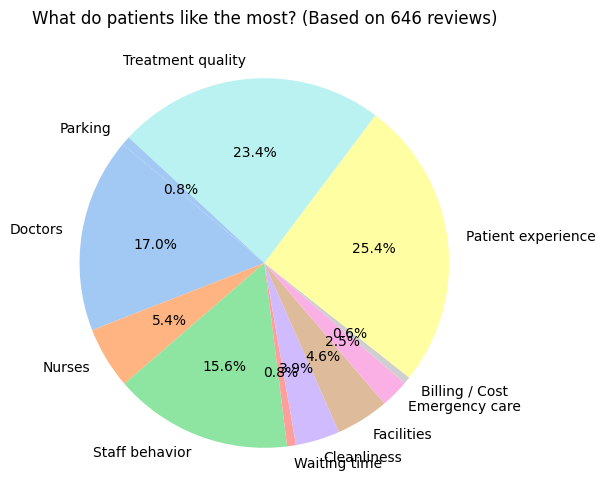


--- Insight Examples ---
Category: DOCTORS
Example: "Highly experienced doctors. Their analysis, interactions and treatment are excellent. "

Category: NURSES
Example: "The staff nurses are down to earth. Their caring and hospitality is highly appreciable. "

Category: STAFF BEHAVIOR
Example: "I have visited to take my second dose and Process was really smooth. Hospitality from all staffs are really appreciable. Shanti tooks good care and provide all details before vaccination. Thank you."

Category: WAITING TIME
Example: "Very crowdy and excessive long queues. Try to avoid and be happy😊😊 …"

Category: CLEANLINESS
Example: "Good and clean hospital. There is great team of doctors and good OT facility. The medical facilities are all great with good in-patient post operative care by doctors, nurses. The housekeeping staff is also good but they can respond to calls from the room a little faster. "

Category: FACILITIES
Example: "Dr. Sheela is a very professional and experienced doctor. Go

In [10]:
# Load Data and Filter for POSITIVE Reviews
df = pd.read_csv("/gdrive/MyDrive/OrchidPharmed/hospital_with_neutral_labels_new.csv")
pos_reviews = df[df['sentiment_label_3class'] == 1]['Feedback'].astype(str).tolist()

print(f"Total Positive Reviews: {len(pos_reviews)}")

# Define the specific business insights you want to track
candidate_labels = [
    "Doctors",
    "Nurses",
    "Staff behavior",
    "Waiting time",
    "Cleanliness",
    "Facilities",
    "Emergency care",
    "Billing / Cost",
    "Patient experience",
    "Treatment quality",
    "Parking"
]

# Load the Zero-Shot Pipeline
# We use device=0 for GPU acceleration if available
device = 0 if torch.cuda.is_available() else -1
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=device)

# Run Classification
# NOTE: Zero-shot is heavy. We process a sample (e.g., first 100) to get a quick result.
# Remove [:100] to run on the whole dataset (takes longer).
# sample_size = 100
reviews_to_test = df[df['sentiment_label_3class'] == 1]['Feedback'].astype(str).tolist()

print(f"Classifying {len(reviews_to_test)} reviews into categories...")
results = classifier(reviews_to_test, candidate_labels, multi_label=False)

# Aggregate Results
aspect_counts = {label: 0 for label in candidate_labels}

for res in results:
    # res['labels'][0] is the category with the highest probability
    top_label = res['labels'][0]
    aspect_counts[top_label] += 1

# Visualize
# Using a Green/Blue palette to signify "Positive" vibes
colors = sns.color_palette('pastel')

plt.figure(figsize=(10, 6))
plt.pie(
    aspect_counts.values(),
    labels=aspect_counts.keys(),
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)
plt.title(f"What do patients like the most? (Based on {len(reviews_to_test)} reviews)")
plt.show()

# Print Examples for each Category
print("\n--- Insight Examples ---")
# Create a quick lookup to show one example per category
examples_found = {label: None for label in candidate_labels}

for res in results:
    top_label = res['labels'][0]
    if examples_found[top_label] is None:
        examples_found[top_label] = res['sequence']

for label, text in examples_found.items():
    if text:
        print(f"Category: {label.upper()}")
        print(f"Example: \"{text}\"\n")

Total Negative Reviews: 304


Device set to use cuda:0


Classifying 304 reviews into categories...


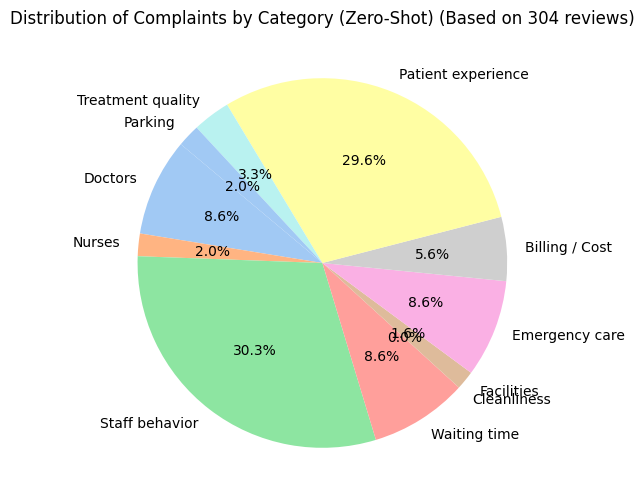


--- Insight Examples ---
Category: DOCTORS
Example: "Dr. Sashidhara, cardiologist took every effort to diagnose the problem and suggested for the bypass and later the Surgeon "

Category: NURSES
Example: "Nurse station support is very poor we have to follow up for everything."

Category: STAFF BEHAVIOR
Example: "Receptionists only want money. They don't care if the doctor is 2 hrs late but give them money."

Category: WAITING TIME
Example: "I went for my father. He has tracheostomy n all issues. They made him wait for 1 hour n said wait if you want to or go."

Category: FACILITIES
Example: "I mean if you are so backdated and illiterate that you don't even know that account statement pdf and physical passbook would show same records then why even are you trying tO get an app for your hospital."

Category: EMERGENCY CARE
Example: "but some of them are are really terrible especially the ones who are in emergency. "

Category: BILLING / COST
Example: "After that incident I lost sensibilit

In [11]:
# Load Data and Filter for Negative Reviews
df = pd.read_csv("/gdrive/MyDrive/OrchidPharmed/hospital_with_neutral_labels_new.csv")
pos_reviews = df[df['sentiment_label_3class'] == 0]['Feedback'].astype(str).tolist()

print(f"Total Negative Reviews: {len(pos_reviews)}")

# Define the specific business insights you want to track
candidate_labels = [
    "Doctors",
    "Nurses",
    "Staff behavior",
    "Waiting time",
    "Cleanliness",
    "Facilities",
    "Emergency care",
    "Billing / Cost",
    "Patient experience",
    "Treatment quality",
    "Parking"
]

# Load the Zero-Shot Pipeline
# We use device=0 for GPU acceleration if available
device = 0 if torch.cuda.is_available() else -1
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=device)

# Run Classification
# NOTE: Zero-shot is heavy. We process a sample (e.g., first 100) to get a quick result.
# Remove [:100] to run on the whole dataset (takes longer).
# sample_size = 100
reviews_to_test = df[df['sentiment_label_3class'] == 0]['Feedback'].astype(str).tolist()

print(f"Classifying {len(reviews_to_test)} reviews into categories...")
results = classifier(reviews_to_test, candidate_labels, multi_label=False)

# Aggregate Results
aspect_counts = {label: 0 for label in candidate_labels}

for res in results:
    # res['labels'][0] is the category with the highest probability
    top_label = res['labels'][0]
    aspect_counts[top_label] += 1

# Visualize
# Using a Green/Blue palette to signify "negative" vibes
colors = sns.color_palette('pastel')

plt.figure(figsize=(10, 6))
plt.pie(
    aspect_counts.values(),
    labels=aspect_counts.keys(),
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)
plt.title(f"Distribution of Complaints by Category (Zero-Shot) (Based on {len(reviews_to_test)} reviews)")
plt.show()

# Print Examples for each Category
print("\n--- Insight Examples ---")
# Create a quick lookup to show one example per category
examples_found = {label: None for label in candidate_labels}

for res in results:
    top_label = res['labels'][0]
    if examples_found[top_label] is None:
        examples_found[top_label] = res['sequence']

for label, text in examples_found.items():
    if text:
        print(f"Category: {label.upper()}")
        print(f"Example: \"{text}\"\n")